In [ ]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=92121a416385e1276a1a5dddbbe28a3f7515e7e96400c2aeac0afde799f1ba42
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

import shap
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
df = pd.read_csv("diabetes.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nOutcome Distribution:")
print(df["Outcome"].value_counts())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome             

In [ ]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features]
y = df["Outcome"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (768, 8)
y Shape: (768,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (614, 8)
Testing Data: (154, 8)


In [ ]:
# Creation of classification model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
#Making prediction:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred[:10])

print("\nPredicted Probabilities:")
print(y_prob[:10])

Predicted Classes:
[1 0 0 0 0 0 0 1 0 1]

Predicted Probabilities:
[0.60971073 0.11835576 0.29346313 0.2508367  0.03320667 0.16852385
 0.4881643  0.92367511 0.08143405 0.8385896 ]


In [ ]:
# Calculate Accuracy and F1-score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7077922077922078
F1 Score: 0.5454545454545454

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [ ]:
# Performing k-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

cv_f1 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Cross-Validation Accuracy Scores:")
print(cv_accuracy)

print("\nMean CV Accuracy:", cv_accuracy.mean())

print("\nCross-Validation F1 Scores:")
print(cv_f1)

print("\nMean CV F1 Score:", cv_f1.mean())

Cross-Validation Accuracy Scores:
[0.77272727 0.7987013  0.77922078 0.75163399 0.76470588]

Mean CV Accuracy: 0.7733978439860792

Cross-Validation F1 Scores:
[0.63917526 0.65168539 0.63829787 0.59574468 0.66037736]

Mean CV F1 Score: 0.6370561125344882


In [ ]:
# Calculate Brier Score
brier = brier_score_loss(y_test, y_prob)

print("Brier Score:", brier)

Brier Score: 0.17541713693275893


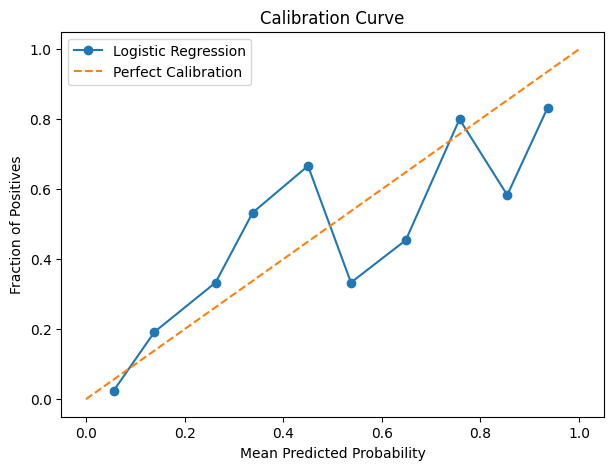

In [ ]:
# Generate Calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")

plt.legend()
plt.show()

SHAP analysis completed.


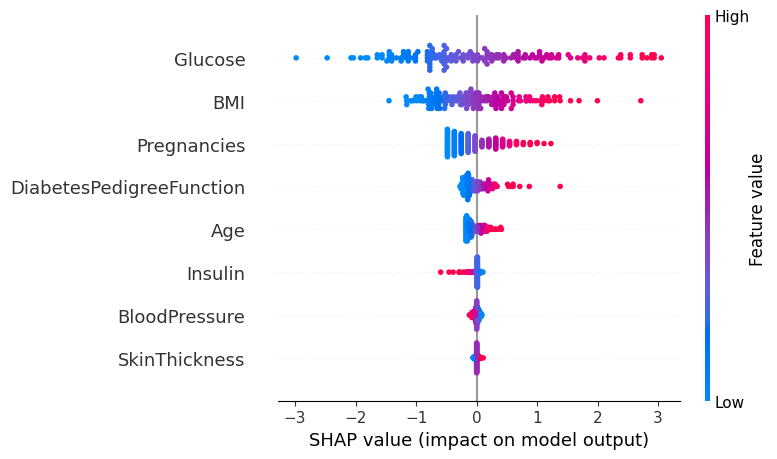

Actual Outcome: 0
Predicted Outcome: 1
Predicted Probability: 0.6097107330034057


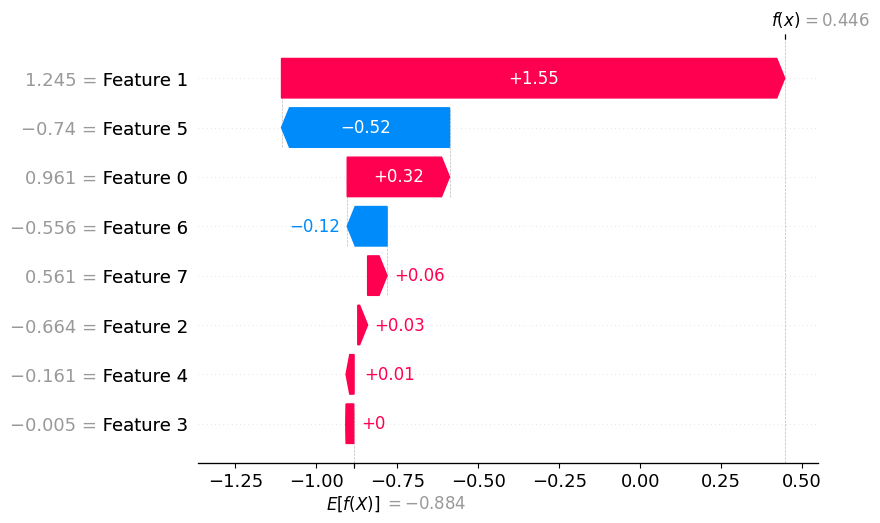

In [ ]:
# Explaining the model using SHAP
scaler = model.named_steps["scaler"]
classifier = model.named_steps["classifier"]

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(
    classifier,
    X_train_scaled
)

shap_values = explainer(X_test_scaled)

print("SHAP analysis completed.")
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)
sample_index = 0

print("Actual Outcome:",
      y_test.iloc[sample_index])

print("Predicted Outcome:",
      y_pred[sample_index])

print("Predicted Probability:",
      y_prob[sample_index])
shap.plots.waterfall(shap_values[sample_index])

In [ ]:
# Final result
results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test F1 Score",
        "Mean CV Accuracy",
        "Mean CV F1 Score",
        "Brier Score"
    ],
    "Value": [
        accuracy,
        f1,
        cv_accuracy.mean(),
        cv_f1.mean(),
        brier
    ]
})

print(results)

             Metric     Value
0     Test Accuracy  0.707792
1     Test F1 Score  0.545455
2  Mean CV Accuracy  0.773398
3  Mean CV F1 Score  0.637056
4       Brier Score  0.175417


In [ ]:
print("Actual Outcome:", y_test.iloc[0])
print("Predicted Outcome:", y_pred[0])
print("Predicted Probability:", y_prob[0])

Actual Outcome: 0
Predicted Outcome: 1
Predicted Probability: 0.6097107330034057
